In [1]:
import numpy as np
import matplotlib.pyplot as plt

def tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i])             # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * (((y[i+1]-y[i])/ h[i]) - ((y[i]-y[i-1])/ h[i-1]))             # Right-hand side vector

    return A, B, C, D


x = np.array([0, 1, 2, 3, 4, 5], dtype=float)

y = np.array([0, 1, 0, 1, 0, 1], dtype=float)


 

A, B, C, D = tridiagonal_matrix(x, y)


In [2]:
def thomas_algorithm(A, B, C, D):

    n = len(B)
    
    A = A.copy()
    B = B.copy()
    C = C.copy()
    D = D.copy()
# Forward elimination
    for i in range(1, n):
        w = A[i-1] / B[i-1]
        B[i] = B[i] - w * C[i-1]
        D[i] = D[i] - w * D[i-1]
# Back substitution
    middle = np.zeros(n)
    middle[-1] = D[-1] / B[-1]
    for i in range(n-2, -1, -1):
        middle[i] = (D[i] - C[i] * middle[i+1]) / B[i]
    return middle

middle = thomas_algorithm(A, B, C, D)
print("Solution:", middle)

Solution: [-4.36363636  5.45454545 -5.45454545  4.36363636]


In [3]:
#compute m (second derivative)
n = len(x)
M = np.zeros(n)

middle = thomas_algorithm(A, B, C, D)

M[1:-1] = middle   # natural spline (ends = 0)

print("M values:", M)

M values: [ 0.         -4.36363636  5.45454545 -5.45454545  4.36363636  0.        ]


In [9]:
def evaluate_spline(x_data, y_data, M, x_query):

    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S
x_vals = np.linspace(min(x), max(x), 200)
y_vals = np.array([
    evaluate_spline(x, y, M, xi)
    for xi in x_vals
    ])


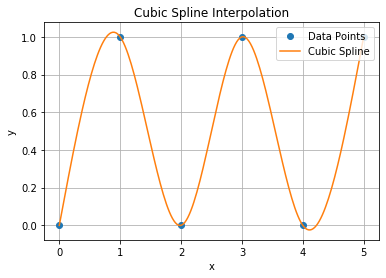

In [10]:
#plotting
plt.figure()
plt.plot(x, y, "o", label="Data Points")      # original points
plt.plot(x_vals, y_vals, label="Cubic Spline")  # smooth curve
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cubic Spline Interpolation")
plt.legend()
plt.grid(True)
plt.show()

The cubic spline passes through all the data points.